In [1]:
import matplotlib.font_manager as fm

# 列出所有支持中文的字体
fonts = [f.name for f in fm.fontManager.ttflist if 'CJK' in f.name or 'Hei' in f.name or 'Song' in f.name]
print(sorted(set(fonts)))


import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 或其他字体名称
plt.rcParams['axes.unicode_minus'] = False

['FangSong', 'Microsoft JhengHei', 'Microsoft YaHei', 'STSong', 'SimHei']


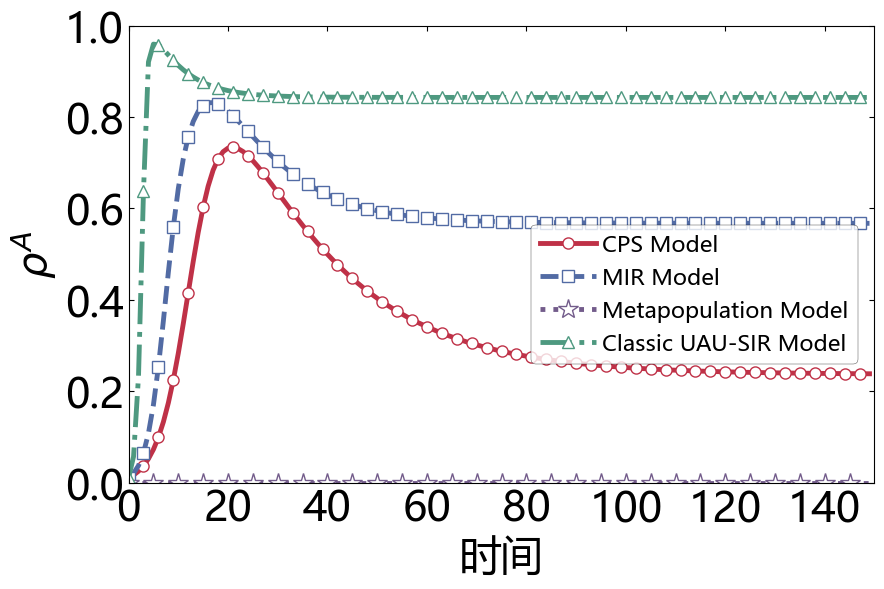

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. 读取两个模型的输出 CSV 文件
# ============================================
cps_file = "CPS_MMCA_mean.csv"
mir_uau_sir_file = "MIR_UAU_SIR_mean.csv"
classic_uau_sir_file = "UAU_SIR_mean.csv"
meta_file = "MIR_SIR_mean.csv"

cps_df = pd.read_csv(cps_file)
mir_uau_sir_file = pd.read_csv(mir_uau_sir_file)
classic_uau_sir_df = pd.read_csv(classic_uau_sir_file)
meta_df = pd.read_csv(meta_file)

# ============================================
# 2. 计算总意识比例 A = AS + AI + AR
# ============================================
cps_df['A'] = cps_df['AS'] + cps_df['AI'] + cps_df['AR']
mir_uau_sir_file['A'] = mir_uau_sir_file['AS'] + mir_uau_sir_file['AI'] + mir_uau_sir_file['AR']
classic_uau_sir_df['A'] = classic_uau_sir_df['AS'] + classic_uau_sir_df['AI'] + classic_uau_sir_df['AR']
meta_df['A'] = meta_df['I'] - meta_df['I']

# ============================================
# 3. 创建画布，绘制对比曲线
# ============================================
plt.figure(figsize=(9, 6))

# CPS 模型（实线，蓝色）
plt.plot(cps_df.index, cps_df['A'],
         label='CPS Model ',
         color='#BF3147', linewidth=3.5, mfc='white',
        marker='o', linestyle = '-', markersize=8, markevery = 3)

# MIR 基线模型（虚线，红色）
plt.plot(mir_uau_sir_file.index, mir_uau_sir_file['A'],
         label='MIR Model ',mfc='white',markersize=8, markevery = 3, marker='s',
         color='#526BA4', linewidth=3.5, linestyle='--')

# 元群模型（点线，黄色）
plt.plot(meta_df.index, meta_df['A'],
         label='Metapopulation Model', mfc='white', markersize=15, markevery = 5, marker='*',
         color='#735C8B', linewidth=3.5, linestyle=':')

# 经典 UAU-SIR 模型（点线，绿色）
plt.plot(classic_uau_sir_df.index, classic_uau_sir_df['A'],
         label='Classic UAU-SIR Model',mfc='white', markersize=8, markevery = 3, marker='^',
         color='#4E9980', linewidth=3.5, linestyle='-.')


# ============================================
# 4. 图表装饰（模板风格）
# ============================================

plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


legend = plt.legend(
    loc=(0.54, 0.26),
    fontsize='16',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    ncol=1,              # 分1列
    handlelength=2.5,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.3)


plt.xlabel('时间',fontsize='30')
# plt.xlabel('time',fontsize='30')
plt.ylabel(r'$\rho^A$',fontsize='30')
plt.xticks(fontsize='30')
plt.xlim(0, 150)  # 设置x轴范围
plt.yticks(fontsize='30')
plt.ylim(0, 1)  # 设置y轴范围


plt.tight_layout()

# 保存图片（高清）
plt.savefig('model_Awareness.pdf', dpi=300, bbox_inches='tight')
plt.show()

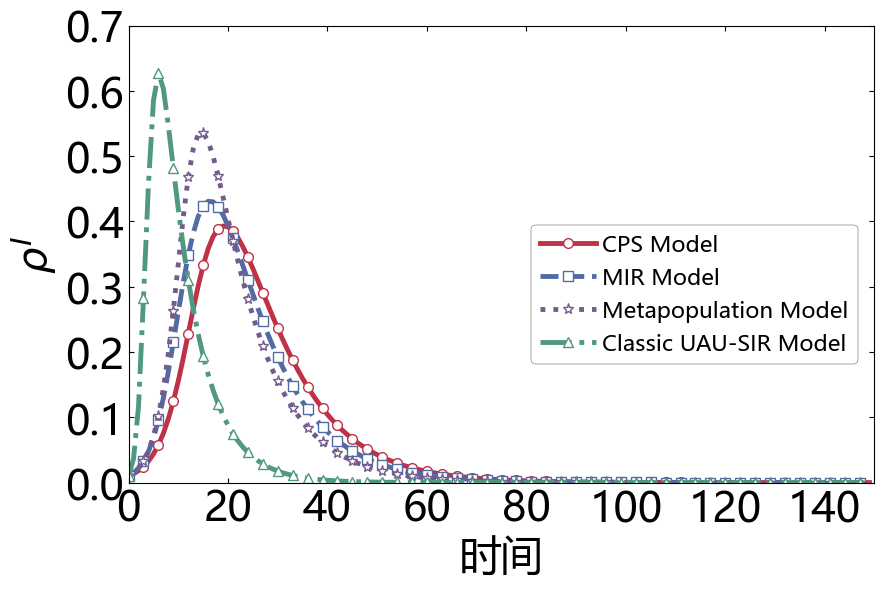

In [3]:


# ============================================
# 2. 计算总体感染比例 AI 
# ============================================
cps_df['I'] = cps_df['AI'] 
mir_uau_sir_file['I'] = mir_uau_sir_file['AI'] 
classic_uau_sir_df['I'] =  classic_uau_sir_df['AI'] 
meta_df['I'] = meta_df['I'] 

# ============================================
# 3. 创建画布，绘制对比曲线
# ============================================
plt.figure(figsize=(9, 6))

# CPS 模型（实线，蓝色）
plt.plot(cps_df.index, cps_df['I'],
         label='CPS Model ',
         color='#BF3147', linewidth=3.5, mfc='white',
        marker='o', linestyle = '-', markersize=7, markevery = 3)

# MIR 基线模型（虚线，红色）
plt.plot(mir_uau_sir_file.index, mir_uau_sir_file['I'],
         label='MIR Model ',mfc='white',markersize=7, markevery = 3, marker='s',
         color='#526BA4', linewidth=3.5, linestyle='--')

# 元群模型（点线，黄色）
plt.plot(meta_df.index, meta_df['I'],
         label='Metapopulation Model', mfc='white', markersize=8, markevery = 3, marker='*',
         color='#735C8B', linewidth=3.5, linestyle=':')

# 经典 UAU-SIR 模型（点线，绿色）
plt.plot(classic_uau_sir_df.index, classic_uau_sir_df['I'],
         label='Classic UAU-SIR Model',mfc='white', markersize=7, markevery = 3, marker='^',
         color='#4E9980', linewidth=3.5, linestyle='-.')


# ============================================
# 4. 图表装饰（模板风格）
# ============================================
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


legend = plt.legend(
    loc=(0.54, 0.26),
    fontsize='16',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    ncol=1,              # 分1列
    handlelength=2.5,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.3)


plt.xlabel('时间',fontsize='30')
# plt.xlabel('time',fontsize='30')
plt.ylabel(r'$\rho^I$',fontsize='30')
plt.xticks(fontsize='30')
plt.xlim(0, 150)  # 设置x轴范围
plt.yticks(fontsize='30')
plt.ylim(0, 0.7)  # 设置y轴范围


plt.tight_layout()


# 保存图片（高清）
plt.savefig('model_Infection.pdf', dpi=300, bbox_inches='tight')
plt.show()